In [5]:
import gzip
import glob
import csv
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#Système étudié :
PMF='../data/pmf_data/total/'
bil_exp='../data/SUPP_hydrophobicity/bilayer_wat_data.dat'
dlpc_exp='../data/SUPP_hydrophobicity/wat_dlpc_data.dat'
out_dir='../plot/'

In [6]:
#Fonctions

def PMF_residue(acid):
    dfpmf=pd.read_table(PMF+f'{acid}/pmf_{acid}.dat'.lower(), sep="\s+")
    return dfpmf

def coeff_corr(x_coor, y_coor):
    #formula: r=sum((x_i-x)*(y_i-y))/sqrt(sum((x_i-x)**2*(y_i-y)**2))
    #mean calculation
    x=np.average(x_coor)
    y=np.average(y_coor)
    #nominator calculation
    N=np.sum((x_coor-x)*(y_coor-y))
    #demoninator calculation
    D=np.sqrt(np.sum((x_coor-x)**2)*np.sum((y_coor-y)**2))
    r=N/D
    return r

def least_square(X, Y):
    # Mean X and Y
    mean_x = np.mean(X)
    mean_y = np.mean(Y)
    # Total number of values
    n = len(X)
    # Using the formula to calculate m and c
    numer = 0
    denom = 0
    for i in range(n):
        numer += (X[i] - mean_x) * (Y[i] - mean_y)
        denom += (X[i] - mean_x) ** 2
    m = numer / denom
    c = mean_y - (m * mean_x)
    # Cannot use Rank 1 matrix in scikit learn
    X = X.reshape((m, 1))
    # Creating Model
    reg = LinearRegression()
    # Fitting training data
    reg = reg.fit(X, Y)
    # Y Prediction
    Y_pred = reg.predict(X)
    # Calculating R2 Score
    r2_score = reg.score(X, Y)
    return r2_score

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def plot_regression(x, y):
    """
    Trace la courbe de régression pour les points (x, y) et affiche le coefficient de corrélation.

    :param x: Liste ou tableau numpy contenant les valeurs x.
    :param y: Liste ou tableau numpy contenant les valeurs y.
    """
    # Vérification que les tailles de x et y correspondent
    if len(x) != len(y):
        raise ValueError("Les tailles des listes x et y doivent être identiques.")

    # Calcul de la régression linéaire
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    # Calcul des valeurs prédites pour la ligne de régression
    y_pred = slope * np.array(x) + intercept

    # Affichage des résultats
    print(f"Équation de la droite : y = {slope:.3f}x + {intercept:.3f}")
    print(f"Coefficient de corrélation (R) : {r_value:.3f}")
    print(f"Coefficient de détermination (R²) : {r_value**2:.3f}")
    return x, y_pred
    

In [7]:
aa_name=['SCA', 'SCV', 'SCL', 'SCI', 'SCP', 'SCHD', 'SCHE', 'SCHP', 'SCW',
         'SCY', 'SCM', 'SCC', 'SCCM', 'SCF', 'SCS', 'SCT', 'SCK', 'SCKN', 'SCR',
         'SCRN', 'SCE', 'SCEN', 'SCD', 'SCDN','SCQ', 'SCN']

aa_symbol=['ALA', 'VAL', 'LEU', 'ILE', 'PRO', 'HSD', 'HSE', 'HSP', 'TRP',
           'TYR', 'MET', 'CYS', 'CYSM', 'PHE', 'SER', 'THR', 'LYS', 'LYSN', 'ARG',
           'ARGN', 'GLU', 'GLUN', 'ASP','ASPN','GLN', 'ASN']

# ── Regional free-energy definition (manuscript, revised method) ──────────
#   ΔG_region = −k_B T ln( Σ_{z∈region} P(z) ) + C_water
#   with  P(z) = exp(−PMF(z)/k_B T)  and the same log-sum-exp applied to
#   a bulk-water slab that plays the role of C_water. The reported quantity
#   is therefore a regional occupancy free energy referenced to bulk water,
#   rather than the PMF value at a single z-bin.

kB = 0.0083144626                     # kJ/(mol·K)
T  = 300.0                            # simulation temperature (K)
kT = kB * T

# z-windows (Å from bilayer center); adjust here if needed.
center_region    = (0.0,  5.0)        # hydrophobic core
interface_region = (15.0, 24.0)       # headgroup / interfacial region
water_region     = (40.0, 50.0)       # bulk-water reference slab

def regional_dG(z, pmf, se, region):
    """Return (ΔG, σ) for a z-window using −kT ln Σ exp(−PMF/kT).
    Errors are propagated from per-bin standard errors assuming
    independent bins and Boltzmann weights."""
    zlo, zhi = region
    m = (z >= zlo) & (z <= zhi)
    pmf_r, se_r = pmf[m], se[m]
    shift = pmf_r.min()                              # numerical stability
    w = np.exp(-(pmf_r - shift) / kT)
    S = w.sum()
    dG = -kT * np.log(S) + shift
    weights = w / S                                  # ∂ΔG/∂PMF(z)
    dG_err = np.sqrt(np.sum((weights * se_r) ** 2))
    return dG, dG_err

df_pmf = pd.DataFrame(columns=['#resid', 'PMF_i', 'std_err_pmf_i',
                               'PMF_c', 'std_err_pmf_c'])

for i in range(len(aa_name)):
    acid = aa_name[i]
    temp = PMF_residue(acid)
    z   = temp['z'].to_numpy()
    pmf = temp['mean'].to_numpy()
    se  = temp['se'].to_numpy()

    dG_int, err_int = regional_dG(z, pmf, se, interface_region)
    dG_cen, err_cen = regional_dG(z, pmf, se, center_region)
    dG_wat, err_wat = regional_dG(z, pmf, se, water_region)

    # Reference to bulk water (C_water term).
    pmfi = dG_int - dG_wat
    stdi = np.sqrt(err_int**2 + err_wat**2)
    pmfc = dG_cen - dG_wat
    stdc = np.sqrt(err_cen**2 + err_wat**2)

    if i == 0:
        print(f'center region    : z ∈ [{center_region[0]}, {center_region[1]}] Å')
        print(f'interface region : z ∈ [{interface_region[0]}, {interface_region[1]}] Å')
        print(f'water reference  : z ∈ [{water_region[0]}, {water_region[1]}] Å')

    df_pmf.loc[len(df_pmf.index)] = [aa_symbol[i], pmfi, stdi, pmfc, stdc]

display(df_pmf)


center region    : z ∈ [0.0, 5.0] Å
interface region : z ∈ [15.0, 24.0] Å
water reference  : z ∈ [40.0, 50.0] Å


,#resid,PMF_i,std_err_pmf_i,PMF_c,std_err_pmf_c
0,ALA,0.241971,0.122474,-6.588710,0.109686
1,VAL,-8.145857,0.730516,-17.104792,0.562527
2,LEU,-8.973266,0.855154,-18.857052,0.614812
3,ILE,-9.401921,0.727581,-19.144577,0.522895
4,PRO,0.192088,0.075091,4.719457,0.114459
5,HSD,2.521110,0.035637,20.941459,0.023115
6,HSE,3.412433,0.033952,20.955966,0.045891
7,HSP,2.640301,0.038730,21.147042,0.008380
8,TRP,-11.189752,0.369847,-7.515229,0.337131
9,TYR,-9.039468,0.423865,-2.255436,0.449193


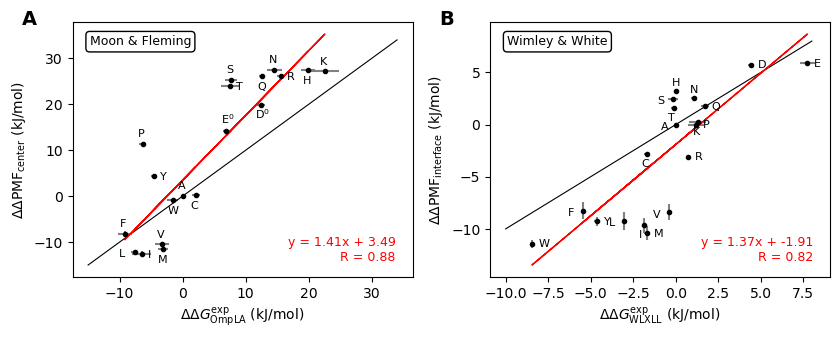

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

# ── Panel A: Moon & Fleming (DLPC) vs Center ──────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, 3.5))

# --- Panel A ---
df_dlpc = pd.read_table(dlpc_exp, sep="\s+", skiprows=[0])
k = 4.184
df_dlpc['OmpLA'] = df_dlpc['OmpLA'].multiply(k)
df_dlpc['std_err'] = df_dlpc['std_err'].multiply(abs(k))

aa_list1_a = ['ALA', 'VAL', 'LEU', 'ILE', 'PRO', 'HIS', 'TRP',
              'TYR', 'MET', 'CYS', 'PHE', 'SER', 'THR', 'LYS',
              'ARG', 'GLU', 'ASP', 'GLN', 'ASN']
aa_list2_a = ['ALA', 'VAL', 'LEU', 'ILE', 'PRO', 'HSE', 'TRP',
              'TYR', 'MET', 'CYS', 'PHE', 'SER', 'THR', 'LYS',
              'ARG', 'GLUN', 'ASPN', 'GLN', 'ASN']
aa_letter_a = ['A', 'V', 'L', 'I', 'P', 'H', 'W',
               'Y', 'M', 'C', 'F', 'S', 'T', 'K',
               'R', 'E$^0$', 'D$^0$', 'Q', 'N']

x_coor_a, y_coor_a = [], []
for i in range(len(aa_list1_a)):
    name1, name2 = aa_list1_a[i], aa_list2_a[i]
    if i == 0:
        df1 = df_dlpc[df_dlpc['pH'] <= 7]
        df2 = df1[df1['#resid'] == name1]
        DG_ref = df2.iloc[0]['OmpLA']
        df2_pmf = df_pmf[df_pmf['#resid'] == name2]
        PMF_ref = df2_pmf.iloc[0]['PMF_c']
    df1 = df_dlpc[df_dlpc['pH'] <= 7]
    df2 = df1[df1['#resid'] == name1]
    DG = df2.iloc[0]['OmpLA'] - DG_ref
    df2_pmf = df_pmf[df_pmf['#resid'] == name2]
    PMF_val = df2_pmf.iloc[0]['PMF_c'] - PMF_ref
    x_err = df2.iloc[0]['std_err']
    y_err = df2_pmf.iloc[0]['std_err_pmf_c']
    x_coor_a.append(DG)
    y_coor_a.append(PMF_val)
    ax1.errorbar(DG, PMF_val, xerr=x_err, yerr=y_err, color='k', fmt='.', ecolor='grey')
    # Label positioning
    if aa_letter_a[i] in ['L']:
        ax1.text(DG - 2.5, PMF_val - 1, aa_letter_a[i], fontsize=8) #left
    elif aa_letter_a[i] in ['I', 'R', 'Y', 'T']:
        ax1.text(DG + 1, PMF_val - 0.8, aa_letter_a[i], fontsize=8) #right
    elif aa_letter_a[i] in ['P', 'E$^0$', 'F', 'K', 'N', 'V', 'A', 'S']:
        ax1.text(DG - 0.8, PMF_val + 1.5, aa_letter_a[i], fontsize=8) #above
    elif aa_letter_a[i] in ['H', 'D$^0$', 'M', 'C', 'Q', 'W']:
        ax1.text(DG - 0.8, PMF_val - 3, aa_letter_a[i], fontsize=8) #below
    else:
        ax1.text(DG, PMF_val, aa_letter_a[i], fontsize=8)

x_line = np.arange(-15, 35)
ax1.plot(x_line, x_line, color='k', lw=0.8)
slope_a, intercept_a, r_a, _, _ = linregress(x_coor_a, y_coor_a)
x_pred_a = np.array(x_coor_a)
y_pred_a = slope_a * x_pred_a + intercept_a
ax1.plot(x_pred_a, y_pred_a, color='r', linewidth=1)
ax1.text(0.95, 0.05, f'y = {slope_a:.2f}x + {intercept_a:.2f}\nR = {r_a:.2f}',
         fontsize=9, color='red', transform=ax1.transAxes, ha='right', va='bottom')
ax1.text(0.05, 0.95, 'Moon & Fleming', fontsize=9, transform=ax1.transAxes,
         ha='left', va='top', bbox=dict(facecolor='none', edgecolor='black', boxstyle='round,pad=0.3'))
ax1.set_xlabel('$\\Delta\\Delta G^{\\mathrm{exp}}_{\\mathrm{OmpLA}}$ (kJ/mol)')
ax1.set_ylabel('$\\Delta\\Delta \\mathrm{PMF}_{\\mathrm{center}}$ (kJ/mol)')
ax1.text(-0.15, 1.05, 'A', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')

# --- Panel B: Wimley & White (POPC bilayer) vs Interface ──────────────────

df_bil = pd.read_table(bil_exp, sep="\s+", skiprows=[0])
k = -4.184
df_bil['DeltaG_WLXLL'] = df_bil['DeltaG_WLXLL'].multiply(k)
df_bil['std_err_G'] = df_bil['std_err_G'].multiply(abs(k))

aa_list1_b = ['ALA', 'VAL', 'LEU', 'ILE', 'PRO', 'HIS', 'TRP',
              'TYR', 'MET', 'CYS', 'PHE', 'SER', 'THR', 'LYS',
              'ARG', 'GLU', 'ASP', 'GLN', 'ASN']
aa_list2_b = ['ALA', 'VAL', 'LEU', 'ILE', 'PRO', 'HSE', 'TRP',
              'TYR', 'MET', 'CYS', 'PHE', 'SER', 'THR', 'LYS',
              'ARG', 'GLU', 'ASP', 'GLN', 'ASN']
aa_letter_b = ['A', 'V', 'L', 'I', 'P', 'H', 'W',
               'Y', 'M', 'C', 'F', 'S', 'T', 'K',
               'R', 'E', 'D', 'Q', 'N']

x_coor_b, y_coor_b = [], []
for i in range(len(aa_list1_b)):
    name1, name2 = aa_list1_b[i], aa_list2_b[i]
    if i == 0:
        df1 = df_bil[df_bil['pH'] >= 7]
        df2 = df1[df1['#resid'] == name1]
        DG_ref = df2.iloc[0]['DeltaG_WLXLL']
        df2_pmf = df_pmf[df_pmf['#resid'] == name2]
        PMF_ref = df2_pmf.iloc[0]['PMF_i']
    df1 = df_bil[df_bil['pH'] >= 7]
    df2 = df1[df1['#resid'] == name1]
    DG = df2.iloc[0]['DeltaG_WLXLL'] - DG_ref
    df2_pmf = df_pmf[df_pmf['#resid'] == name2]
    PMF_val = df2_pmf.iloc[0]['PMF_i'] - PMF_ref
    x_err = abs(df2.iloc[0]['std_err_G'])
    y_err = df2_pmf.iloc[0]['std_err_pmf_i']
    x_coor_b.append(DG)
    y_coor_b.append(PMF_val)
    ax2.errorbar(DG, PMF_val, xerr=x_err, yerr=y_err, color='k', fmt='.', ecolor='grey')
    # Label positioning
    if aa_letter_b[i] in ['F', 'A', 'V', 'L', 'S']:
        ax2.text(DG - 0.9, PMF_val - 0.5, aa_letter_b[i], fontsize=8)
    elif aa_letter_b[i] in ['R', 'D', 'E', 'Q', 'W', 'M', 'Y', 'P']:
        ax2.text(DG + 0.4, PMF_val - 0.3, aa_letter_b[i], fontsize=8)
    elif aa_letter_b[i] in ['H', 'N']:
        ax2.text(DG - 0.2, PMF_val + 0.5, aa_letter_b[i], fontsize=8)
    elif aa_letter_b[i] in ['C', 'I', 'T', 'K']:
        ax2.text(DG - 0.3, PMF_val - 1.2, aa_letter_b[i], fontsize=8)
    else:
        ax2.text(DG, PMF_val, aa_letter_b[i], fontsize=8)

x_line = np.arange(-10, 9)
ax2.plot(x_line, x_line, color='k', lw=0.8)
slope_b, intercept_b, r_b, _, _ = linregress(x_coor_b, y_coor_b)
x_pred_b = np.array(x_coor_b)
y_pred_b = slope_b * x_pred_b + intercept_b
ax2.plot(x_pred_b, y_pred_b, color='r', linewidth=1)
ax2.text(0.95, 0.05, f'y = {slope_b:.2f}x + {intercept_b:.2f}\nR = {r_b:.2f}',
         fontsize=9, color='red', transform=ax2.transAxes, ha='right', va='bottom')
ax2.text(0.05, 0.95, 'Wimley & White', fontsize=9, transform=ax2.transAxes,
         ha='left', va='top', bbox=dict(facecolor='none', edgecolor='black', boxstyle='round,pad=0.3'))
ax2.set_xlabel('$\\Delta\\Delta G^{\\mathrm{exp}}_{\\mathrm{WLXLL}}$ (kJ/mol)')
ax2.set_ylabel('$\\Delta\\Delta \\mathrm{PMF}_{\\mathrm{interface}}$ (kJ/mol)')
ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig(out_dir + 'FigureS10.png', bbox_inches='tight', dpi=600)
plt.show()